In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from collections import Counter


In [2]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")
print(df.shape)
print(df.columns.tolist()[:10])
df.head()

(229249, 80)
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,is_attack
0,22,166,1,1,0,0,0,0,0.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,0
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,0
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,0
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,0
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN,0


In [3]:
feature_cols = [col for col in df.columns if col not in ["Label", "is_attack"]]

X= df[feature_cols]
y= df["is_attack"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("Number of features: ", len(feature_cols))

X shape:  (229249, 78)
y shape:  (229249,)
Number of features:  78


In [4]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    average_precision_score
)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [6]:
print(type(lr_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [10]:
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC: {rf_auc:.4f}")


Logistic Regression AUC: 0.9999
Random Forest AUC: 1.0000


In [11]:
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     45843
           1       0.01      1.00      0.01         7

    accuracy                           0.98     45850
   macro avg       0.50      0.99      0.50     45850
weighted avg       1.00      0.98      0.99     45850

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45843
           1       1.00      0.86      0.92         7

    accuracy                           1.00     45850
   macro avg       1.00      0.93      0.96     45850
weighted avg       1.00      1.00      1.00     45850



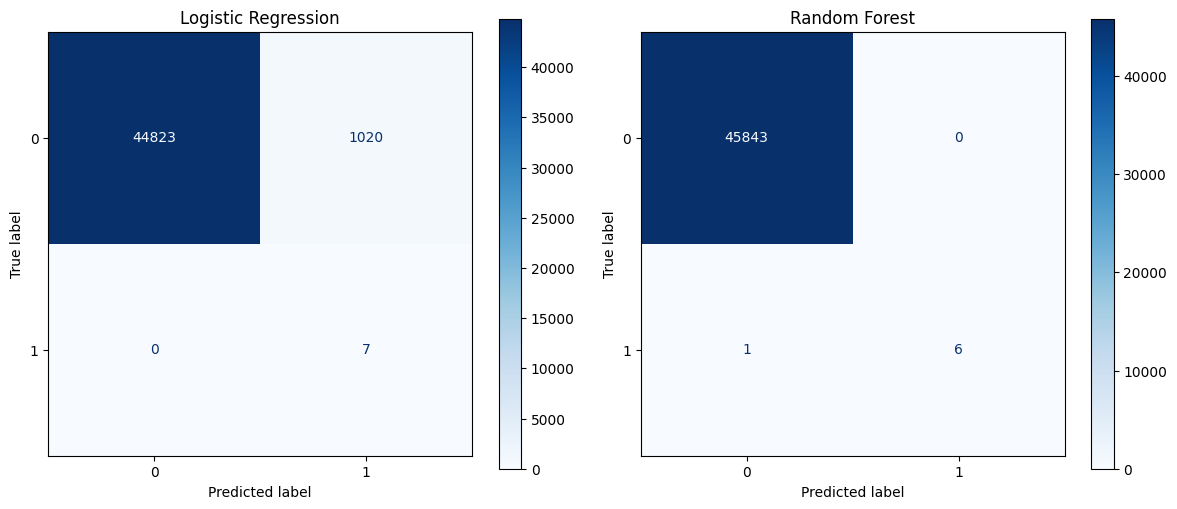

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=ax[0], cmap="Blues")
ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax[1], cmap="Blues")
ax[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

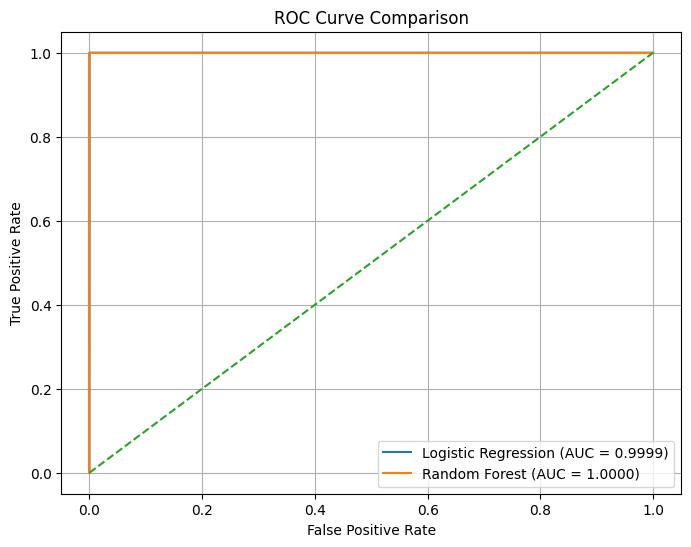

In [14]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.4f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()